In [1]:
import pandas as pd
import numpy as np
import sqlite3
from pathlib import Path
import vectorbt as vbt
import sys
import json
from tqdm.auto import tqdm

sys.path.insert(0, str(Path('.').resolve().parent))
from dema_strat import load_ohlcv, vbt_frame, free
from constants import CASH, COMMISSION, SESSIONS

TABLE_NAME = "f1_session"
SMOOTH_PERIOD = 12
RISK_PER_TRADE = 100.0


In [2]:
def load_data(file_path, *, verbose=False, use_vwap=False):
    return load_ohlcv(file_path, use_cache=True, add_vwap=use_vwap, verbose=verbose)

def session_mask(index, session):
    start = pd.Timestamp(session["start"]).time()
    end = pd.Timestamp(session["end"]).time()
    tod = np.array(index.to_series().dt.time.values)
    if start <= end:
        return (tod >= start) & (tod < end)
    return (tod >= start) | (tod < end)

def make_signals(data, n1=9, atr_period=14, sl_mult=1.0, rr_ratio=0.5, use_vwap=False, smooth_period=SMOOTH_PERIOD):
    close = data["Close"]
    high = data["High"]
    low = data["Low"]

    ema1 = vbt.indicators.MA.run(close, window=n1, ewm=True)
    smoothed = vbt.indicators.MA.run(ema1.ma, window=smooth_period, ewm=True)
    atr = vbt.indicators.ATR.run(high, low, close, window=atr_period)

    sl_dist = sl_mult * atr.atr
    tp_dist = rr_ratio * sl_dist
    sl_pct = sl_dist / close
    tp_pct = tp_dist / close

    long_mask = (smoothed.ma > ema1.ma) & np.isfinite(atr.atr) & (atr.atr > 0)
    short_mask = (ema1.ma > smoothed.ma) & np.isfinite(atr.atr) & (atr.atr > 0)

    if use_vwap:
        long_mask = long_mask & (close > data["VWAP"])
        short_mask = short_mask & (close < data["VWAP"])

    return pd.DataFrame({
        "ema1": ema1.ma,
        "smoothed": smoothed.ma,
        "atr": atr.atr,
        "sl_pct": sl_pct,
        "tp_pct": tp_pct,
        "long": long_mask,
        "short": short_mask,
    })

def run_backtest(data, n1=9, atr_period=14, sl_mult=1.0, rr_ratio=0.5, use_vwap=False, smooth_period=SMOOTH_PERIOD, session=None):
    signals = make_signals(data, n1=n1, atr_period=atr_period, sl_mult=sl_mult, rr_ratio=rr_ratio, use_vwap=use_vwap, smooth_period=smooth_period)
    freq = data.index.to_series().diff().median()

    long_signal = signals["long"].to_numpy(dtype=bool)
    short_signal = signals["short"].to_numpy(dtype=bool)

    n = len(data)
    in_session = np.ones(n, dtype=bool)
    session_end = np.zeros(n, dtype=bool)
    if session is not None:
        in_session = session_mask(data.index, session)
        next_in = np.empty(n, dtype=bool)
        next_in[:-1] = in_session[1:]
        next_in[-1] = False
        session_end = in_session & ~next_in

    long_signal = long_signal & in_session & ~session_end
    short_signal = short_signal & in_session & ~session_end
    exits_long = short_signal | session_end
    exits_short = long_signal | session_end

    close_np = data["Close"].to_numpy(dtype=np.float64)

    sl_pct_np = signals["sl_pct"].to_numpy(dtype=np.float64)
    size_value = np.where(sl_pct_np > 0, RISK_PER_TRADE / sl_pct_np, 0.0)

    portfolio = vbt.Portfolio.from_signals(
        close=close_np,
        entries=long_signal,
        exits=exits_long,
        short_entries=short_signal,
        short_exits=exits_short,
        init_cash=CASH,
        fees=COMMISSION,
        size=size_value,
        size_type="value",
        freq=freq,
        sl_stop=signals["sl_pct"].to_numpy(dtype=np.float64),
        tp_stop=signals["tp_pct"].to_numpy(dtype=np.float64),
    )

    return portfolio, portfolio.stats(), signals

In [3]:
file_path = Path("~/market_data/XAUUSD/XAUUSD_M15.csv").expanduser()
data = load_data(file_path, verbose=True)

portfolio, stats, signals = run_backtest(
    data,
    n1=5,
    rr_ratio=2,
    atr_period=18,
    session=SESSIONS[1],
    sl_mult=3,
    use_vwap=1,
    smooth_period=12,
)
print(stats)

trades = portfolio.trades.records_readable
print(trades.head(10))
print(f"Total trades: {len(trades)}")

[loader] cache hit: XAUUSD_M15__cache_v1.parquet


Start                                                 0
End                                              139917
Period                               1457 days 11:30:00
Start Value                                     50000.0
End Value                                  51507.390058
Total Return [%]                                3.01478
Benchmark Return [%]                         184.221285
Max Gross Exposure [%]                       159.251865
Total Fees Paid                            15064.763948
Max Drawdown [%]                               8.040485
Max Drawdown Duration                 542 days 18:30:00
Total Trades                                       1880
Total Closed Trades                                1880
Total Open Trades                                     0
Open Trade PnL                                      0.0
Win Rate [%]                                   41.43617
Best Trade [%]                                 5.487051
Worst Trade [%]                               -1

In [4]:
trades_df = trades.copy()
# Map integer index to actual datetime from data index
trades_df['entry_date'] = pd.to_datetime(data.index[trades_df['Entry Timestamp'].astype(int)]).date
trades_df['exit_date'] = pd.to_datetime(data.index[trades_df['Exit Timestamp'].astype(int)]).date
# Use exit date for daily PnL attribution
daily_pnl = trades_df.groupby('exit_date')['PnL'].sum().reset_index()
daily_pnl.columns = ['date', 'daily_pnl']
print(daily_pnl.head(20))
print(f"Number of trading days: {len(daily_pnl)}")
print(f"Daily PnL stats:\n{daily_pnl['daily_pnl'].describe()}")
print(f"Total PnL: ${daily_pnl['daily_pnl'].sum():.2f}")

          date   daily_pnl
0   2020-01-02  252.113599
1   2020-01-03   48.432285
2   2020-01-06 -124.872781
3   2020-01-07   57.780793
4   2020-01-09 -156.624988
5   2020-01-10 -351.179903
6   2020-01-13  -93.252842
7   2020-01-14  -28.539976
8   2020-01-15 -147.013821
9   2020-01-16  110.064557
10  2020-01-17  193.642823
11  2020-01-20   23.989689
12  2020-01-21    0.235023
13  2020-01-22   23.452037
14  2020-01-23 -242.993368
15  2020-01-24  257.795644
16  2020-01-27    8.278999
17  2020-01-28  215.439678
18  2020-01-29   -7.796617
19  2020-01-30   44.289557
Number of trading days: 1372
Daily PnL stats:
count    1372.000000
mean        1.098681
std       142.317328
min      -475.019117
25%      -112.646112
50%       -10.934428
75%        81.785610
max       973.416395
Name: daily_pnl, dtype: float64
Total PnL: $1507.39


In [5]:
class TopstepXCombine:
    def __init__(self, starting_balance=50000, profit_target=3000, max_loss_limit=2000,
                 daily_loss_limit=1000, consistency_target_pct=0.5, min_days=2):
        self.starting_balance = starting_balance
        self.profit_target = profit_target
        self.max_loss_limit = max_loss_limit
        self.daily_loss_limit = daily_loss_limit
        self.consistency_target = profit_target * consistency_target_pct  # $1500
        self.min_days = min_days
    
    def simulate(self, daily_pnl_series, seed=None):
        if seed is not None:
            np.random.seed(seed)
        
        # Shuffle daily PnL to simulate different market conditions
        shuffled = daily_pnl_series.sample(frac=1, random_state=seed).reset_index(drop=True)
        
        balance = self.starting_balance
        mll = self.starting_balance - self.max_loss_limit  # $48,000
        days_traded = 0
        max_daily_profit = 0
        total_profit = 0
        
        for i, pnl in enumerate(shuffled):
            balance += pnl
            total_profit += pnl
            days_traded += 1
            
            if pnl > max_daily_profit:
                max_daily_profit = pnl
            
            # Check MLL (trailing from EOD balance)
            if balance <= mll:
                return {'passed': False, 'reason': 'MLL_hit', 'days': days_traded, 'balance': balance, 'total_profit': total_profit, 'max_daily_profit': max_daily_profit}
            
            # Update trailing MLL
            new_mll = balance - self.max_loss_limit
            if new_mll > mll:
                mll = new_mll
            # MLL locks at starting balance
            if mll >= self.starting_balance:
                mll = self.starting_balance
            
            # Check profit target
            if total_profit >= self.profit_target:
                # Check consistency: best day < 50% of profit target
                if max_daily_profit < self.consistency_target:
                    if days_traded >= self.min_days:
                        return {'passed': True, 'reason': 'profit_target', 'days': days_traded, 'balance': balance, 'total_profit': total_profit, 'max_daily_profit': max_daily_profit}
                else:
                    return {'passed': False, 'reason': 'consistency_fail', 'days': days_traded, 'balance': balance, 'total_profit': total_profit, 'max_daily_profit': max_daily_profit}
        
        # Ran out of days
        return {'passed': False, 'reason': 'insufficient_days', 'days': days_traded, 'balance': balance, 'total_profit': total_profit, 'max_daily_profit': max_daily_profit}

class TopstepXFA:
    def __init__(self, max_loss_limit=2000, target_profit=2000):
        self.max_loss_limit = max_loss_limit
        self.target_profit = target_profit
        self.mll = -max_loss_limit  # -$2000
    
    def simulate(self, daily_pnl_series, seed=None):
        if seed is not None:
            np.random.seed(seed + 1000000)
        
        shuffled = daily_pnl_series.sample(frac=1, random_state=seed + 1000000).reset_index(drop=True)
        
        balance = 0
        total_profit = 0
        days_traded = 0
        
        for i, pnl in enumerate(shuffled):
            balance += pnl
            total_profit += pnl
            days_traded += 1
            
            # Check MLL
            if balance <= self.mll:
                return {'funded': False, 'reason': 'MLL_hit', 'days': days_traded, 'balance': balance, 'total_profit': total_profit}
            
            # MLL trails up to $0
            new_mll = balance - self.max_loss_limit
            if new_mll > self.mll:
                self.mll = new_mll
            if self.mll >= 0:
                self.mll = 0
            
            # Check if funded (made target profit)
            if total_profit >= self.target_profit:
                return {'funded': True, 'reason': 'target_reached', 'days': days_traded, 'balance': balance, 'total_profit': total_profit}
        
        return {'funded': False, 'reason': 'insufficient_profit', 'days': days_traded, 'balance': balance, 'total_profit': total_profit}

In [6]:
combine = TopstepXCombine()
xfa = TopstepXFA(target_profit=2000)

n_sims = 1000
combine_results = []
xfa_results = []

for i in tqdm(range(n_sims), desc="Monte Carlo simulations"):
    cr = combine.simulate(daily_pnl['daily_pnl'], seed=i)
    combine_results.append(cr)
    
    if cr['passed']:
        xr = xfa.simulate(daily_pnl['daily_pnl'], seed=i)
        xfa_results.append(xr)
    else:
        xfa_results.append({'funded': False, 'reason': 'combine_failed', 'days': 0, 'balance': 0, 'total_profit': 0})

Monte Carlo simulations:   0%|          | 0/1000 [00:00<?, ?it/s]

In [7]:
combine_df = pd.DataFrame(combine_results)
xfa_df = pd.DataFrame(xfa_results)

pass_rate = combine_df['passed'].mean()
funded_rate = xfa_df['funded'].mean()
conditional_funded = xfa_df[combine_df['passed']]['funded'].mean() if combine_df['passed'].any() else 0

print(f"=== TopstepX 50K Monte Carlo Results ({n_sims} simulations) ===")
print(f"\n--- Trading Combine (Evaluation) ---")
print(f"Pass Rate: {pass_rate:.2%} ({combine_df['passed'].sum()}/{n_sims})")
print(f"\nReasons for failure:")
print(combine_df[~combine_df['passed']]['reason'].value_counts())
if combine_df['passed'].any():
    print(f"\nDays to pass (successful): {combine_df[combine_df['passed']]['days'].mean():.1f} avg")
    print(f"Total profit at pass: ${combine_df[combine_df['passed']]['total_profit'].mean():.2f} avg")
    print(f"Max daily profit at pass: ${combine_df[combine_df['passed']]['max_daily_profit'].mean():.2f} avg")

print(f"\n--- Express Funded Account (XFA) ---")
print(f"Funded Rate (overall): {funded_rate:.2%} ({xfa_df['funded'].sum()}/{n_sims})")
print(f"Funded Rate (conditional on passing combine): {conditional_funded:.2%}")
print(f"\nXFA failure reasons:")
print(xfa_df[~xfa_df['funded']]['reason'].value_counts())
if xfa_df['funded'].any():
    print(f"Days to funded: {xfa_df[xfa_df['funded']]['days'].mean():.1f} avg")
    print(f"Total profit at funded: ${xfa_df[xfa_df['funded']]['total_profit'].mean():.2f} avg")

=== TopstepX 50K Monte Carlo Results (1000 simulations) ===

--- Trading Combine (Evaluation) ---
Pass Rate: 28.40% (284/1000)

Reasons for failure:
reason
MLL_hit    716
Name: count, dtype: int64

Days to pass (successful): 234.8 avg
Total profit at pass: $3096.77 avg
Max daily profit at pass: $562.87 avg

--- Express Funded Account (XFA) ---
Funded Rate (overall): 0.80% (8/1000)
Funded Rate (conditional on passing combine): 2.82%

XFA failure reasons:
reason
combine_failed    716
MLL_hit           276
Name: count, dtype: int64
Days to funded: 64.2 avg
Total profit at funded: $2063.43 avg


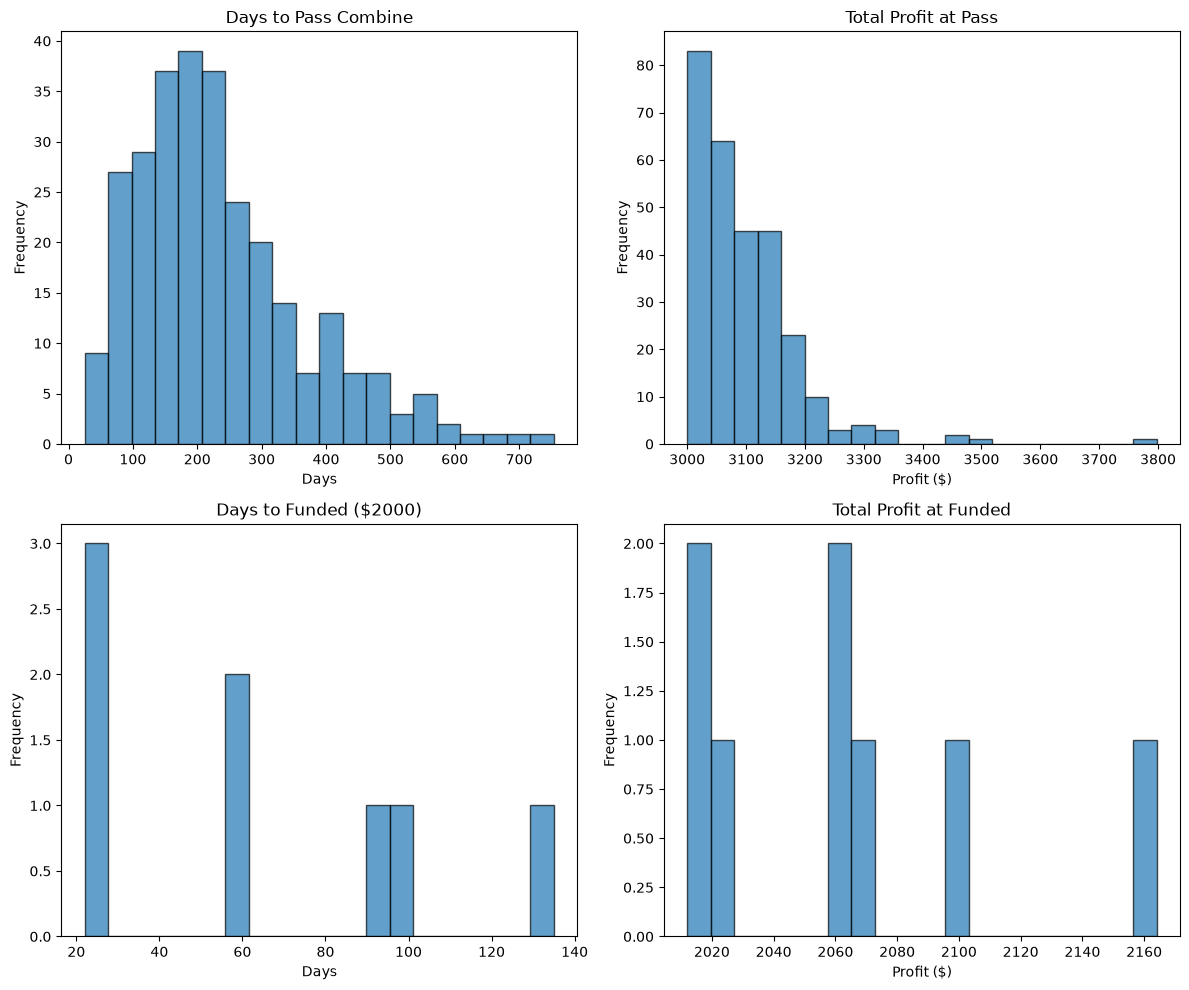

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

if combine_df['passed'].any():
    axes[0, 0].hist(combine_df[combine_df['passed']]['days'], bins=20, alpha=0.7, edgecolor='black')
    axes[0, 0].set_title('Days to Pass Combine')
    axes[0, 1].hist(combine_df[combine_df['passed']]['total_profit'], bins=20, alpha=0.7, edgecolor='black')
    axes[0, 1].set_title('Total Profit at Pass')
else:
    axes[0, 0].text(0.5, 0.5, 'No passes', ha='center', va='center', transform=axes[0, 0].transAxes)
    axes[0, 1].text(0.5, 0.5, 'No passes', ha='center', va='center', transform=axes[0, 1].transAxes)
axes[0, 0].set_xlabel('Days')
axes[0, 0].set_ylabel('Frequency')
axes[0, 1].set_xlabel('Profit ($)')
axes[0, 1].set_ylabel('Frequency')

if xfa_df['funded'].any():
    axes[1, 0].hist(xfa_df[xfa_df['funded']]['days'], bins=20, alpha=0.7, edgecolor='black')
    axes[1, 0].set_title('Days to Funded ($2000)')
    axes[1, 1].hist(xfa_df[xfa_df['funded']]['total_profit'], bins=20, alpha=0.7, edgecolor='black')
    axes[1, 1].set_title('Total Profit at Funded')
else:
    axes[1, 0].text(0.5, 0.5, 'No funded', ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 1].text(0.5, 0.5, 'No funded', ha='center', va='center', transform=axes[1, 1].transAxes)
axes[1, 0].set_xlabel('Days')
axes[1, 0].set_ylabel('Frequency')
axes[1, 1].set_xlabel('Profit ($)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [9]:
print("=== Summary Statistics ===")
print(f"Combine Pass Rate: {pass_rate:.2%}")
print(f"Funded Rate (overall): {funded_rate:.2%}")
print(f"Funded Rate (conditional): {conditional_funded:.2%}")
print(f"\nExpected value per combine attempt: ${pass_rate * conditional_funded * 2000:.2f}")
print(f"(Assumes $2000 profit once funded)")

print(f"\n=== Per-simulation details (first 10) ===")
for i in range(min(10, n_sims)):
    cr = combine_results[i]
    xr = xfa_results[i]
    status = "PASS" if cr['passed'] else "FAIL"
    funded = "FUNDED" if xr['funded'] else "NOT_FUNDED"
    print(f"Sim {i:3d}: {status:4s} | {cr['reason']:20s} | {funded:10s} | Days: {cr['days']:2d} | Profit: ${cr['total_profit']:7.2f} | MaxDay: ${cr['max_daily_profit']:7.2f}")

=== Summary Statistics ===
Combine Pass Rate: 28.40%
Funded Rate (overall): 0.80%
Funded Rate (conditional): 2.82%

Expected value per combine attempt: $16.00
(Assumes $2000 profit once funded)

=== Per-simulation details (first 10) ===
Sim   0: FAIL | MLL_hit              | NOT_FUNDED | Days: 152 | Profit: $-1085.00 | MaxDay: $ 309.07
Sim   1: FAIL | MLL_hit              | NOT_FUNDED | Days: 227 | Profit: $-1820.17 | MaxDay: $ 347.57
Sim   2: PASS | profit_target        | FUNDED     | Days: 348 | Profit: $3088.05 | MaxDay: $ 386.94
Sim   3: FAIL | MLL_hit              | NOT_FUNDED | Days: 301 | Profit: $-1427.86 | MaxDay: $ 508.26
Sim   4: FAIL | MLL_hit              | NOT_FUNDED | Days: 95 | Profit: $-1676.27 | MaxDay: $ 347.57
Sim   5: PASS | profit_target        | NOT_FUNDED | Days: 87 | Profit: $3005.59 | MaxDay: $ 392.19
Sim   6: PASS | profit_target        | NOT_FUNDED | Days: 164 | Profit: $3033.33 | MaxDay: $ 392.19
Sim   7: PASS | profit_target        | NOT_FUNDED | Days: 363

In [10]:
free(data, signals)